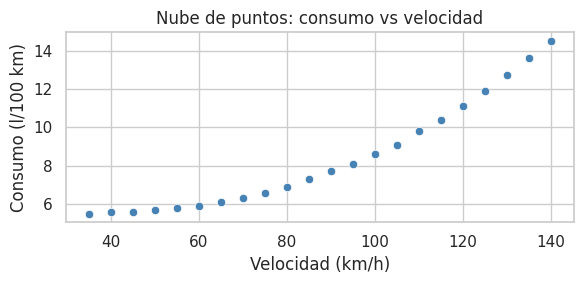


=== Modelo de regresión lineal ===
                            OLS Regression Results                            
Dep. Variable:                consumo   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     199.0
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           7.43e-12
Time:                        09:59:30   Log-Likelihood:                -27.391
No. Observations:                  22   AIC:                             58.78
Df Residuals:                      20   BIC:                             60.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1

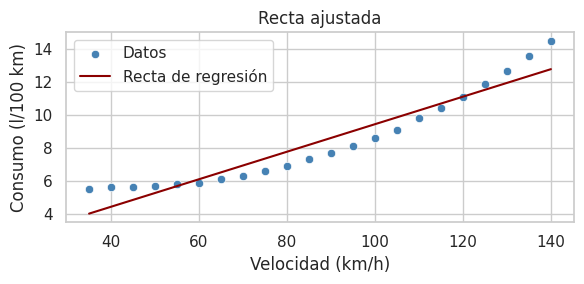

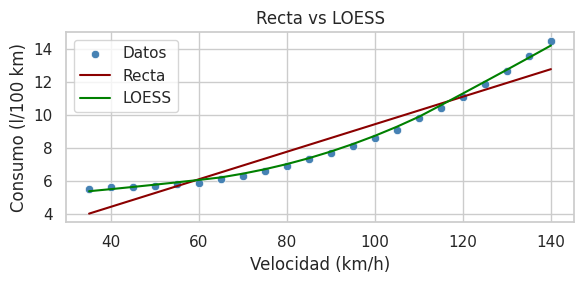


=== Predicción para 130 km/h ===
        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  11.951666  0.314171      11.296317      12.607014      9.999749   

   obs_ci_upper  
0     13.903583  

=== Interpretaciones ===
- b1 indica cómo cambia el consumo por cada km/h adicional.
- Para 10 km/h adicionales: 10 * b1.
- El R² indica qué proporción de la variabilidad del consumo explica la velocidad.
- Si LOESS muestra curvatura, el modelo lineal no es adecuado en todo el rango.
- Predecir a 130 km/h puede ser extrapolación si no hay datos en esa zona.
- Extrapolar es arriesgado porque el consumo real suele crecer de forma no lineal.
- Si solo hubiera datos entre 60 y 100 km/h, el modelo sería fiable solo ahí.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

# =========================
# 1. Carga de datos
# =========================
file_path = "Datos.xlsx"
sheet_name = "Ej2"

df = pd.read_excel(file_path, sheet_name=sheet_name)

x = df["velocidad"]
y = df["consumo"]

sns.set(style="whitegrid")

# =========================
# 2. Nube de puntos
# =========================
plt.figure(figsize=(6, 3))
sns.scatterplot(x=x, y=y, color="steelblue")
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Consumo (l/100 km)")
plt.title("Nube de puntos: consumo vs velocidad")
plt.tight_layout()
plt.show()

print()  # línea en blanco

# =========================
# 3. Ajuste del modelo lineal
# =========================
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

print("=== Modelo de regresión lineal ===")
print(model.summary())

print()  # línea en blanco

b0 = model.params["const"]
b1 = model.params["velocidad"]

print(f"Intercepto b0 = {b0:.4f}")
print(f"Pendiente b1 = {b1:.4f} l/100km por km/h")

print()  # línea en blanco

# =========================
# 4. Nube + recta ajustada
# =========================
plt.figure(figsize=(6, 3))
sns.scatterplot(x=x, y=y, color="steelblue", label="Datos")

x_line = np.linspace(x.min(), x.max(), 100)
X_line = sm.add_constant(x_line)
y_line = model.predict(X_line)

plt.plot(x_line, y_line, color="darkred", label="Recta de regresión")
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Consumo (l/100 km)")
plt.title("Recta ajustada")
plt.legend()
plt.tight_layout()
plt.show()

print()  # línea en blanco

# =========================
# 5. LOESS
# =========================
loess_fit = lowess(y, x, frac=0.6)

plt.figure(figsize=(6, 3))
sns.scatterplot(x=x, y=y, color="steelblue", label="Datos")
plt.plot(x_line, y_line, color="darkred", label="Recta")
plt.plot(loess_fit[:, 0], loess_fit[:, 1], color="green", label="LOESS")
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Consumo (l/100 km)")
plt.title("Recta vs LOESS")
plt.legend()
plt.tight_layout()
plt.show()

print()  # línea en blanco

# =========================
# 6. Predicción para 130 km/h
# =========================
x0 = 130

X0 = pd.DataFrame({
    "const": [1],
    "velocidad": [x0]
})

pred = model.get_prediction(X0)
pred_summary = pred.summary_frame(alpha=0.05)

print(f"=== Predicción para {x0} km/h ===")
print(pred_summary)

print()  # línea en blanco

# =========================
# 7. Interpretaciones sugeridas
# =========================
print("=== Interpretaciones ===")
print("- b1 indica cómo cambia el consumo por cada km/h adicional.")
print("- Para 10 km/h adicionales: 10 * b1.")
print("- El R² indica qué proporción de la variabilidad del consumo explica la velocidad.")
print("- Si LOESS muestra curvatura, el modelo lineal no es adecuado en todo el rango.")
print("- Predecir a 130 km/h puede ser extrapolación si no hay datos en esa zona.")
print("- Extrapolar es arriesgado porque el consumo real suele crecer de forma no lineal.")
print("- Si solo hubiera datos entre 60 y 100 km/h, el modelo sería fiable solo ahí.")
